In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amohankumar/bone-break-classifier-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bone-break-classifier-dataset' dataset.
Path to dataset files: /kaggle/input/bone-break-classifier-dataset


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
amohankumar_bone_break_classifier_dataset_path = kagglehub.dataset_download('amohankumar/bone-break-classifier-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'bone-break-classifier-dataset' dataset.
Data source import complete.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
!pip install pytorch-lightning
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image
import zipfile  # Agrega esta línea
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.4 MB/s eta 0:00:00


In [ ]:
# Definir la transformación de datos
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Crear el conjunto de datos
dataset = datasets.ImageFolder(root="/kaggle/input/bone-break-classifier-dataset", transform=transform)

# Clases del conjunto de datos
class_names = dataset.classes


print(class_names)
print(len(class_names))

['Avulsion fracture', 'Comminuted fracture', 'Compression-Crush fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Intra-articular fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
12


In [ ]:
# Crear el directorio "datasets" si no existe
!mkdir datasets


In [ ]:
# Funciones para comprimir y extraer archivos zip
def create_zip(source_folder, destination_zip):
    # Remove existing zip file if it exists, to avoid potential corruption/lock issues
    if os.path.exists(destination_zip):
        os.remove(destination_zip)

    # Check if source_folder exists and is a directory
    if not os.path.isdir(source_folder):
        print(f"Warning: Source folder does not exist or is not a directory: {source_folder}. Skipping zipping.")
        return

    with zipfile.ZipFile(destination_zip, 'w', zipfile.ZIP_DEFLATED) as zip_ref:
        files_found = False
        for root, dirs, files in os.walk(source_folder):
            for file in files:
                files_found = True
                file_path = os.path.join(root, file)
                zip_ref.write(file_path, arcname=os.path.relpath(file_path, source_folder))

        if not files_found:
            print(f"Warning: No files found in source folder: {source_folder}. Creating an empty zip file.")

def extract_zip(zip_file, destination_folder):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(destination_folder)

In [ ]:
# Crear y extraer archivos zip para cada clase

# Ensure the output directory for zips exists
zip_output_dir = '/kaggle/working/zips'
os.makedirs(zip_output_dir, exist_ok=True)

for name in class_names:
    name2 = name.replace(' ', '_')
    # Corrected source_folder path
    source_folder = os.path.join(amohankumar_bone_break_classifier_dataset_path, name)
    destination_zip = os.path.join(zip_output_dir, name2 + '_folder.zip')
    destination_folder = '/kaggle/working/datasets/' + name2

    create_zip(source_folder, destination_zip)
    extract_zip(destination_zip, destination_folder)


In [ ]:
!ls datasets


In [ ]:
# Clase para el módulo de datos
class DataModule(pl.LightningDataModule):
    def __init__(self, transform=transform, batch_size=32):
        super().__init__()
        self.root_dir = "/kaggle/working/datasets"
        self.transform = transform
        self.batch_size = batch_size

    def setup(self, stage=None):
        dataset = datasets.ImageFolder(root=self.root_dir, transform=self.transform)
        n_data = len(dataset)
        n_train = int(0.6 * n_data)
        n_valid = int(0.2 * n_data)
        n_test = n_data - n_train - n_valid

        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [n_train, n_valid, n_test])

        self.train_dataset = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        self.val_dataset = DataLoader(val_dataset, batch_size=self.batch_size)
        self.test_dataset = DataLoader(test_dataset, batch_size=self.batch_size)

    def train_dataloader(self):
        return self.train_dataset

    def val_dataloader(self):
        return self.val_dataset

    def test_dataloader(self):
        return self.test_dataset

In [ ]:

# Clase del modelo MobileNetV2
class MobileNetV2Model(LightningModule):
    def __init__(self, num_classes=len(class_names)):
        super(MobileNetV2Model, self).__init__()

        # Cargar el modelo MobileNetV2 preentrenado
        self.mobilenet = models.mobilenet_v2()

        # Ajustar la capa clasificadora para el número de clases en tu conjunto de datos
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, X):
        return self.mobilenet(X)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        X, y = train_batch
        y_hat = self(X)
        loss = F.cross_entropy(y_hat, y)
        pred = y_hat.argmax(dim=1, keepdim=True)
        acc = pred.eq(y.view_as(pred)).sum().item() / y.shape[0]
        self.log("train_loss", loss)
        self.log("train_acc", acc)
        return loss

    def validation_step(self, val_batch, batch_idx):
        X, y = val_batch
        y_hat = self(X)
        loss = F.cross_entropy(y_hat, y)
        pred = y_hat.argmax(dim=1, keepdim=True)
        acc = pred.eq(y.view_as(pred)).sum().item() / y.shape[0]
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, test_batch, batch_idx):
        X, y = test_batch
        y_hat = self(X)
        loss = F.cross_entropy(y_hat, y)
        pred = y_hat.argmax(dim=1, keepdim=True)
        acc = pred.eq(y.view_as(pred)).sum().item() / y.shape[0]
        self.log("test_loss", loss)
        self.log("test_acc", acc)

In [ ]:
# Crear el módulo de datos y el modelo
datamodule = DataModule()
datamodule.setup()
model = MobileNetV2Model()


In [ ]:
import pytorch_lightning as pl

# Crear el módulo de datos y el modelo
datamodule = DataModule()
datamodule.setup()
model = MobileNetV2Model()

# Entrenar el modelo
trainer = pl.Trainer(max_epochs=30)
trainer.fit(model, datamodule)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mobilenet │ MobileNetV2 │  2.2 M │ train │     0 │
└───┴───────────┴─────────────┴────────┴───────┴───────┘

Trainable params: 2.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.2 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 213                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed 
in bytes should be converted to RGBA images
  warnings.warn(

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


In [ ]:
# Evaluar el modelo
datamodule.setup(stage='test')
test_loader = datamodule.test_dataloader()
trainer.test(dataloaders=test_loader)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/lightning_logs/version_0/checkpoints/epoch=29-step=960.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/lightning_logs/version_0/checkpoints/epoch=29-step=960.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.4822485148906708     │
│         test_loss         │    1.7425512075424194     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.7425512075424194, 'test_acc': 0.4822485148906708}]

In [ ]:
# Visualizar algunas imágenes
for images, labels in datamodule.train_dataloader():
    break


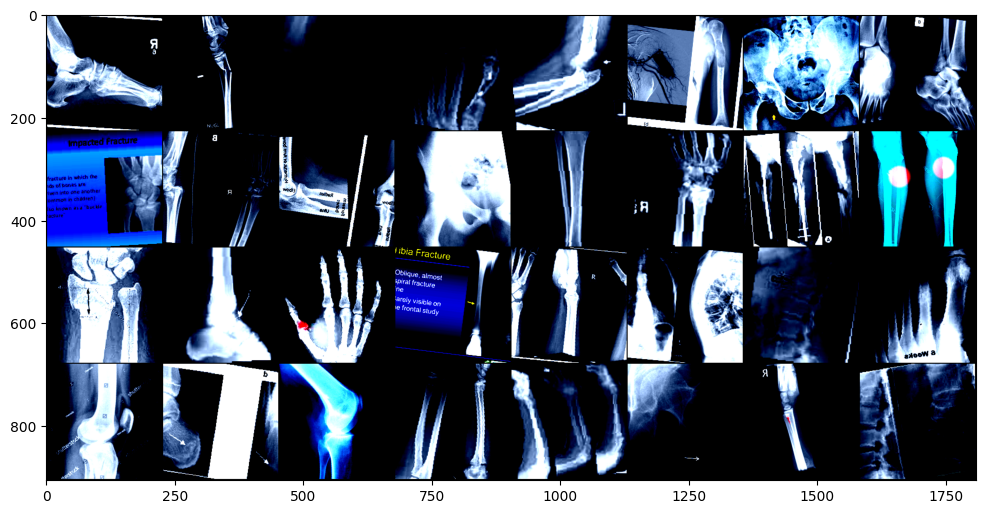

In [ ]:
# Mostrar una cuadrícula de imágenes
im = make_grid(images, nrow=8)
plt.figure(figsize=(12, 12))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))


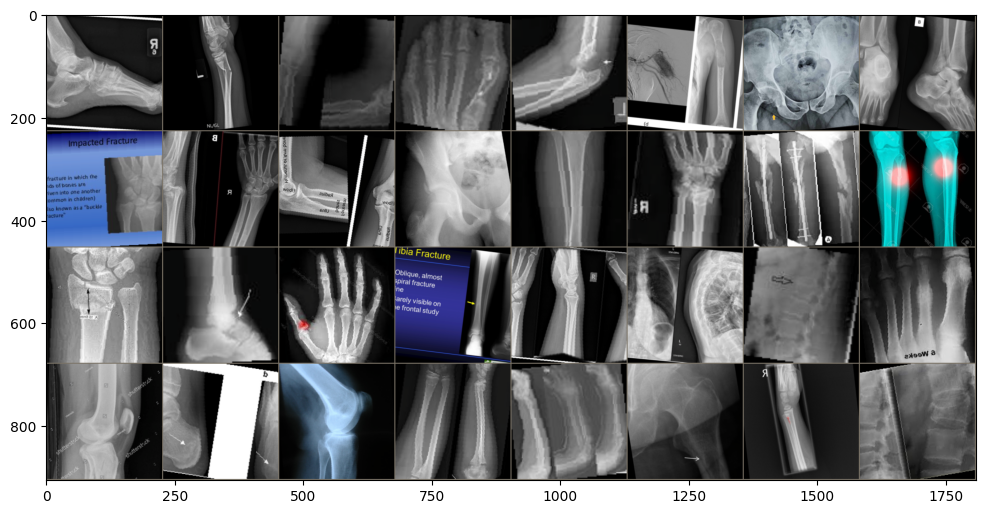

In [ ]:
# Inversa de la normalización para la visualización
inv_normalize = transforms.Normalize(mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                                     std=[1 / 0.229, 1 / 0.224, 1 / 0.225])
im = inv_normalize(im)

plt.figure(figsize=(12, 12))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))


In [ ]:
# Evaluar el modelo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for test_data in datamodule.test_dataloader():
        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())


In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                            precision    recall  f1-score   support

         Avulsion fracture     0.4783    0.7857    0.5946        28
       Comminuted fracture     0.5116    0.5116    0.5116        43
Compression-Crush fracture     0.5000    0.7037    0.5846        27
      Fracture Dislocation     0.7059    0.4286    0.5333        28
       Greenstick fracture     0.4839    0.6000    0.5357        25
         Hairline Fracture     0.5161    0.5926    0.5517        27
         Impacted fracture     0.3333    0.2812    0.3051        32
  Intra-articular fracture     0.6429    0.3750    0.4737        24
     Longitudinal fracture     0.4333    0.4062    0.4194        32
          Oblique fracture     0.6000    0.1429    0.2308        21
     Pathological fracture     0.5135    0.6333    0.5672        30
           Spiral Fracture     0.3684    0.3333    0.3500        21

                  accuracy                         0.4911       338
                 macro avg     0.5073    0.482

In [ ]:
# Guardar el modelo
torch.save(model.state_dict(), "/kaggle/working/model_weights.pth")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, ResNet50, MobileNetV3Small
import matplotlib.pyplot as plt

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = "/kaggle/working/datasets"
val_dir = "/kaggle/working/datasets"

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Added for splitting data into train/val
)

val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2) # Added for splitting data into train/val

train_data = train_gen.flow_from_directory(
    train_dir, # Ensure 'train_dir' is '/kaggle/working/datasets' in the previous cell
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Changed from 'binary' to 'categorical' for multi-class
    subset='training' # Specify subset for training data
)

val_data = val_gen.flow_from_directory(
    val_dir, # Ensure 'val_dir' is '/kaggle/working/datasets' in the previous cell
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Changed from 'binary' to 'categorical' for multi-class
    subset='validation' # Specify subset for validation data
)

Found 1353 images belonging to 12 classes.
Found 332 images belonging to 12 classes.


In [ ]:
def build_model(base_model):
    base_model.trainable = False  # freeze base

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(len(class_names), activation='softmax')(x) # Changed to 12 neurons with softmax

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy', # Changed to categorical_crossentropy
        metrics=['accuracy']
    )

    return model

In [ ]:
base = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_mobile = build_model(base)

history_mobile = model_mobile.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
38/43 ━━━━━━━━━━━━━━━━━━━━ 2s 599ms/step - accuracy: 0.0638 - loss: 2.5736

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 39s 757ms/step - accuracy: 0.0665 - loss: 2.5729 - val_accuracy: 0.0723 - val_loss: 2.4957
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 655ms/step - accuracy: 0.0983 - loss: 2.5206 - val_accuracy: 0.0723 - val_loss: 2.4883
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 628ms/step - accuracy: 0.0990 - loss: 2.4960 - val_accuracy: 0.0843 - val_loss: 2.4843
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 631ms/step - accuracy: 0.1079 - loss: 2.4918 - val_accuracy: 0.1024 - val_loss: 2.4816
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 625ms/step - accuracy: 0.1308 - loss: 2.4647 - val_accuracy: 0.1145 - val_loss: 2.4797
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 26s 608ms/step - accuracy: 0.1138 - loss: 2.4694 - val_accuracy: 0.1084 - val_loss: 2.4779
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 613ms/step - accuracy: 0.1138 - loss: 2.4794 - val_accuracy: 0.1054 - val_loss: 2.4759
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 26s 604ms/step - accuracy: 0.1449 - loss: 2.4402 - val_accuracy: 0.117

In [ ]:
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_resnet = build_model(base)

history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 220s 5s/step - accuracy: 0.0850 - loss: 2.6710 - val_accuracy: 0.0994 - val_loss: 2.6363
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 215s 5s/step - accuracy: 0.0961 - loss: 2.5745 - val_accuracy: 0.0904 - val_loss: 2.5537
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 210s 5s/step - accuracy: 0.1131 - loss: 2.5138 - val_accuracy: 0.1114 - val_loss: 2.5168
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 211s 5s/step - accuracy: 0.1138 - loss: 2.5413 - val_accuracy: 0.1145 - val_loss: 2.4948
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 213s 5s/step - accuracy: 0.1286 - loss: 2.4924 - val_accuracy: 0.1205 - val_loss: 2.4821
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 210s 5s/step - accuracy: 0.1574 - loss: 2.4655 - val_accuracy: 0.1295 - val_loss: 2.4714
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 211s 5s/step - accuracy: 0.1611 - loss: 2.4034 - val_accuracy: 0.1265 - val_loss: 2.4645
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 201s 5s/step - accurac

In [ ]:
def alexnet():
    model = models.Sequential()

    model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
    model.add(layers.MaxPooling2D(3, strides=2))

    model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(3, strides=2))

    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(3, strides=2))

    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(class_names), activation='softmax')) # Changed to len(class_names) neurons with softmax activation

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy', # Changed to categorical_crossentropy
        metrics=['accuracy']
    )

    return model

model_alex = alexnet()

history_alex = model_alex.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step - accuracy: 0.1160 - loss: 2.6662 - val_accuracy: 0.1295 - val_loss: 2.4736
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.1279 - loss: 2.4747 - val_accuracy: 0.1295 - val_loss: 2.4673
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step - accuracy: 0.1279 - loss: 2.4724 - val_accuracy: 0.1295 - val_loss: 2.4684
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.1279 - loss: 2.4737 - val_accuracy: 0.1295 - val_loss: 2.4670
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 155s 4s/step - accuracy: 0.1279 - loss: 2.4724 - val_accuracy: 0.1295 - val_loss: 2.4674
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.1279 - loss: 2.4716 - val_accuracy: 0.1295 - val_loss: 2.4673
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.1279 - loss: 2.4699 - val_accuracy: 0.1295 - val_loss: 2.4674
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.1279 - loss: 2.4715 - val_accuracy: 0.1295 - v

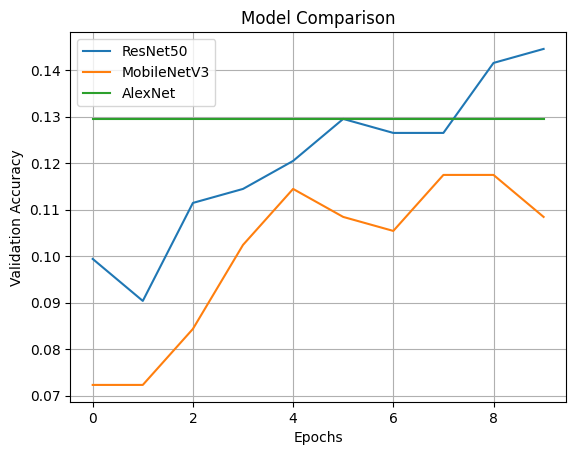

In [ ]:
def plot_history(histories, names):
    for history, name in zip(histories, names):
        plt.plot(history.history['val_accuracy'], label=name)

    plt.legend()
    plt.title("Model Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.grid(True)
    plt.show()


plot_history(
    [history_resnet, history_mobile, history_alex],
    ["ResNet50", "MobileNetV3", "AlexNet"]
)

In [ ]:
# Unfreeze base model
base.trainable = True   # Unfreeze the entire base model

# Freeze most layers, train last 20
for layer in base.layers[:-20]:
    layer.trainable = False

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_resnet_ft = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 267s 6s/step - accuracy: 0.0813 - loss: 0.7118 - val_accuracy: 0.1205 - val_loss: 0.6664
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 254s 6s/step - accuracy: 0.0798 - loss: 0.5891 - val_accuracy: 0.1295 - val_loss: 0.6437
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 253s 6s/step - accuracy: 0.0968 - loss: 0.5246 - val_accuracy: 0.1325 - val_loss: 0.5737
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 253s 6s/step - accuracy: 0.1035 - loss: 0.4888 - val_accuracy: 0.1235 - val_loss: 0.5405
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 264s 6s/step - accuracy: 0.1013 - loss: 0.4631 - val_accuracy: 0.1175 - val_loss: 0.5205


In [ ]:
model_mobile.layers[0].trainable = True # The build_model function sets the base model as the first layer

# Unfreeze the base model
base.trainable = True

# Freeze most layers, train last 20
for layer in base.layers[:-20]:
    layer.trainable = False

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_mobile_ft = model_mobile.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 594ms/step - accuracy: 0.1360 - loss: 0.6919 - val_accuracy: 0.1084 - val_loss: 0.6842
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 588ms/step - accuracy: 0.1279 - loss: 0.6840 - val_accuracy: 0.1114 - val_loss: 0.6797
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 40s 560ms/step - accuracy: 0.1419 - loss: 0.6766 - val_accuracy: 0.1114 - val_loss: 0.6738
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 576ms/step - accuracy: 0.1456 - loss: 0.6697 - val_accuracy: 0.1024 - val_loss: 0.6669
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 574ms/step - accuracy: 0.1382 - loss: 0.6610 - val_accuracy: 0.1024 - val_loss: 0.6591


In [ ]:
model_alex.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_alex_ft = model_alex.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.1279 - loss: 0.6746 - val_accuracy: 0.1295 - val_loss: 0.6725
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.1279 - loss: 0.6708 - val_accuracy: 0.1295 - val_loss: 0.6687
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step - accuracy: 0.1279 - loss: 0.6669 - val_accuracy: 0.1295 - val_loss: 0.6647
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.1279 - loss: 0.6627 - val_accuracy: 0.1295 - val_loss: 0.6605
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.1279 - loss: 0.6583 - val_accuracy: 0.1295 - val_loss: 0.6560


### Validation Metrics for Fine-Tuned Models

Plotting Validation Accuracy for Fine-Tuned Models:


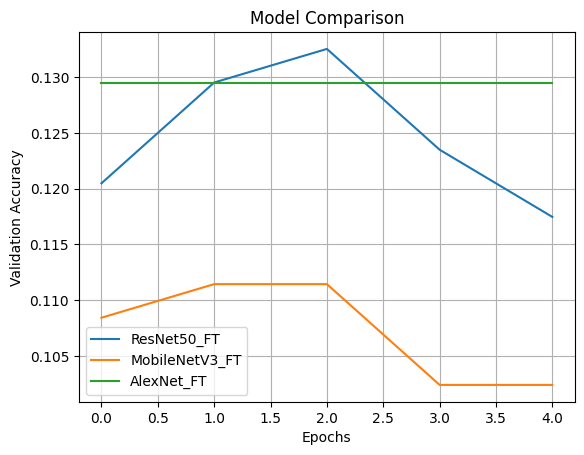


Plotting Validation Loss for Fine-Tuned Models:


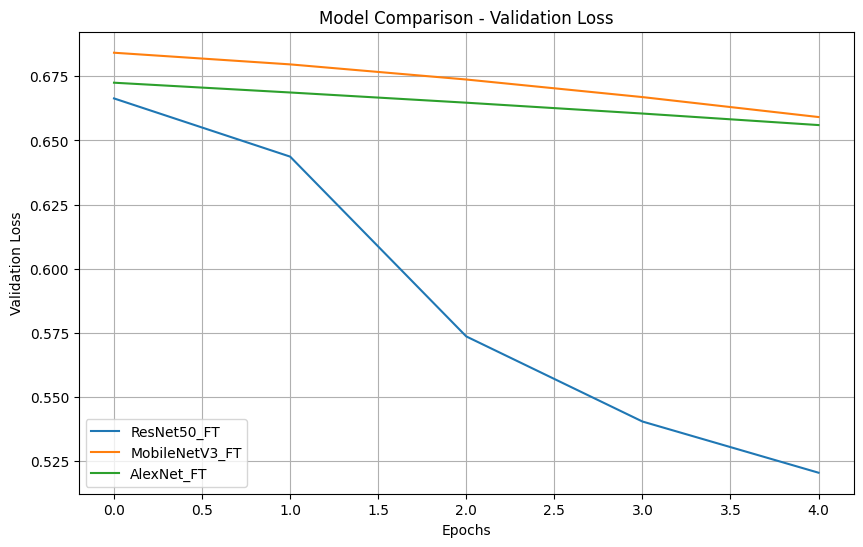

In [ ]:
def plot_history(histories, names):
    for history, name in zip(histories, names):
        plt.plot(history.history['val_accuracy'], label=name)

    plt.legend()
    plt.title("Model Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.grid(True)
    plt.show()

print('Plotting Validation Accuracy for Fine-Tuned Models:')
plot_history(
    [history_resnet_ft, history_mobile_ft, history_alex_ft],
    ["ResNet50_FT", "MobileNetV3_FT", "AlexNet_FT"]
)

def plot_loss_history(histories, names):
    plt.figure(figsize=(10, 6))
    for history, name in zip(histories, names):
        plt.plot(history.history['val_loss'], label=name)

    plt.legend()
    plt.title("Model Comparison - Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Loss")
    plt.grid(True)
    plt.show()

print('\nPlotting Validation Loss for Fine-Tuned Models:')
plot_loss_history(
    [history_resnet_ft, history_mobile_ft, history_alex_ft],
    ["ResNet50_FT", "MobileNetV3_FT", "AlexNet_FT"]
)

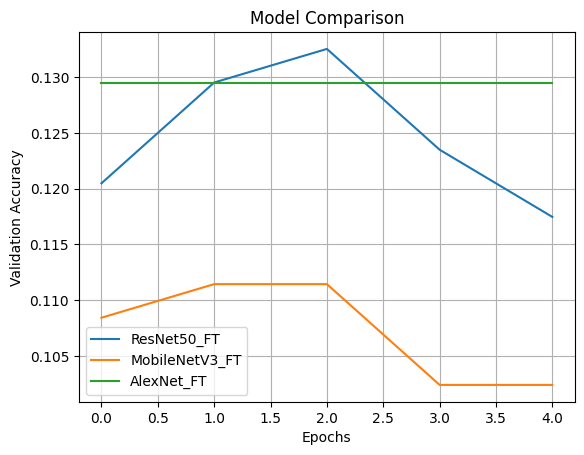

In [ ]:
#validation accuracy graph
plot_history(
    [history_resnet_ft, history_mobile_ft, history_alex_ft],
    ["ResNet50_FT", "MobileNetV3_FT", "AlexNet_FT"]
)

In [ ]:
# Evaluate fine-tuned ResNet50 model
print("Evaluating Fine-Tuned ResNet50:")
loss_resnet, accuracy_resnet = model_resnet.evaluate(val_data)
print(f"ResNet50 Fine-Tuned Validation Loss: {loss_resnet:.4f}")
print(f"ResNet50 Fine-Tuned Validation Accuracy: {accuracy_resnet:.4f}\n")

Evaluating Fine-Tuned ResNet50:
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.1175 - loss: 0.5205
ResNet50 Fine-Tuned Validation Loss: 0.5205
ResNet50 Fine-Tuned Validation Accuracy: 0.1175



In [ ]:
# Evaluate fine-tuned MobileNetV3 model
print("Evaluating Fine-Tuned MobileNetV3:")
loss_mobile, accuracy_mobile = model_mobile.evaluate(val_data)
print(f"MobileNetV3 Fine-Tuned Validation Loss: {loss_mobile:.4f}")
print(f"MobileNetV3 Fine-Tuned Validation Accuracy: {accuracy_mobile:.4f}\n")

Evaluating Fine-Tuned MobileNetV3:
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.1024 - loss: 0.6591
MobileNetV3 Fine-Tuned Validation Loss: 0.6591
MobileNetV3 Fine-Tuned Validation Accuracy: 0.1024



In [ ]:
# Evaluate fine-tuned AlexNet model
print("Evaluating Fine-Tuned AlexNet:")
loss_alex, accuracy_alex = model_alex.evaluate(val_data)
print(f"AlexNet Fine-Tuned Validation Loss: {loss_alex:.4f}")
print(f"AlexNet Fine-Tuned Validation Accuracy: {accuracy_alex:.4f}")

Evaluating Fine-Tuned AlexNet:
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 799ms/step - accuracy: 0.1295 - loss: 0.6560
AlexNet Fine-Tuned Validation Loss: 0.6560
AlexNet Fine-Tuned Validation Accuracy: 0.1295
